# This notebook reproduces following figures: Fig. 4, Fig. 5, Fig. S4.

Following network files were used to simulate the networks:
- nw_iall_pattern_completion_stim.py
- nw_iall_pattern_completion_inhib.py
- nw_ie_pattern_completion_stim.py
- nw_ie_pattern_completion_inhib.py
- nw_iall_engram_pattern_completion_stim.py
- nw_ie_engram_pattern_completion_stim.py

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Fig 4: Co-active ISP enhances stimulation-driven engram recall.

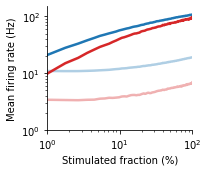

In [3]:
CSV_PATH = "data/fig4_5/iall_pattern_completion_stim_rates_summary.csv"
SHOW_SEM = True

df = pd.read_csv(CSV_PATH)

for c in [
    "stim_level",
    "inh_rate_0_to_196", "inh_rate_196_to_2000",
    "exc_rate_stim_to_784", "exc_rate_784_to_8000",
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["x"] = (df["stim_level"] * 7.0) * 100 / 784.0

rate_cols = [
    "inh_rate_0_to_196",
    "inh_rate_196_to_2000",
    "exc_rate_stim_to_784",
    "exc_rate_784_to_8000",
]

g = df.groupby("x")[rate_cols]
mean_df = g.mean().reset_index()

if SHOW_SEM:
    count_df = g.count().reset_index()
    std_df = g.std(ddof=1).reset_index()
    sem_df = std_df.copy()
    for col in rate_cols:
        sem_df[col] = std_df[col] / np.sqrt(count_df[col].replace(0, np.nan))
else:
    sem_df = None

x = mean_df["x"].to_numpy()

BLUE = "#1f77b4"
RED  = "#d62728"

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.plot(x, mean_df["inh_rate_0_to_196"], color=BLUE, linewidth=2.5, label="Inh 0–196")
ax.plot(x, mean_df["inh_rate_196_to_2000"], color=BLUE, linewidth=2.5, alpha=0.35, label="Inh 196–2000")

ax.plot(x, mean_df["exc_rate_stim_to_784"], color=RED, linewidth=2.5, label="Exc stim→784")
ax.plot(x, mean_df["exc_rate_784_to_8000"], color=RED, linewidth=2.5, alpha=0.35, label="Exc 784→8000")

if SHOW_SEM:
    def shade(ycol, color, alpha):
        y = mean_df[ycol].to_numpy()
        s = sem_df[ycol].to_numpy()
        ax.fill_between(x, y - s, y + s, color=color, alpha=alpha, linewidth=0)

    shade("inh_rate_0_to_196", BLUE, 0.12)
    shade("inh_rate_196_to_2000", BLUE, 0.06)
    shade("exc_rate_stim_to_784", RED, 0.12)
    shade("exc_rate_784_to_8000", RED, 0.06)

ax.set_xlim(1, 100)
ax.set_ylim(1, 150)
ax.set_xlabel("Stimulated fraction (%)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_yscale("log")
ax.set_xscale("log")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


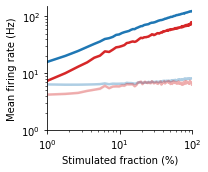

In [4]:
CSV_PATH = "data/fig4_5/ie_pattern_completion_stim_rates_summary.csv"
SHOW_SEM = True

df = pd.read_csv(CSV_PATH)

for c in [
    "stim_level",
    "inh_rate_0_to_196", "inh_rate_196_to_2000",
    "exc_rate_stim_to_784", "exc_rate_784_to_8000",
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["x"] = (df["stim_level"] * 7.0) * 100 / 784.0

rate_cols = [
    "inh_rate_0_to_196",
    "inh_rate_196_to_2000",
    "exc_rate_stim_to_784",
    "exc_rate_784_to_8000",
]

g = df.groupby("x")[rate_cols]
mean_df = g.mean().reset_index()

if SHOW_SEM:
    count_df = g.count().reset_index()
    std_df = g.std(ddof=1).reset_index()
    sem_df = std_df.copy()
    for col in rate_cols:
        sem_df[col] = std_df[col] / np.sqrt(count_df[col].replace(0, np.nan))
else:
    sem_df = None

x = mean_df["x"].to_numpy()

BLUE = "#1f77b4"
RED  = "#d62728"

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.plot(x, mean_df["inh_rate_0_to_196"], color=BLUE, linewidth=2.5, label="Inh 0–196")
ax.plot(x, mean_df["inh_rate_196_to_2000"], color=BLUE, linewidth=2.5, alpha=0.35, label="Inh 196–2000")

ax.plot(x, mean_df["exc_rate_stim_to_784"], color=RED, linewidth=2.5, label="Exc stim→784")
ax.plot(x, mean_df["exc_rate_784_to_8000"], color=RED, linewidth=2.5, alpha=0.35, label="Exc 784→8000")

if SHOW_SEM:
    def shade(ycol, color, alpha):
        y = mean_df[ycol].to_numpy()
        s = sem_df[ycol].to_numpy()
        ax.fill_between(x, y - s, y + s, color=color, alpha=alpha, linewidth=0)

    shade("inh_rate_0_to_196", BLUE, 0.12)
    shade("inh_rate_196_to_2000", BLUE, 0.06)
    shade("exc_rate_stim_to_784", RED, 0.12)
    shade("exc_rate_784_to_8000", RED, 0.06)

ax.set_xlim(1, 100)
ax.set_ylim(1, 150)
ax.set_xlabel("Stimulated fraction (%)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_yscale("log")
ax.set_xscale("log")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.legend(frameon=False)
plt.tight_layout()
plt.show()


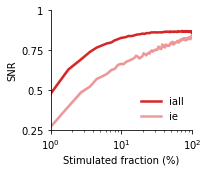

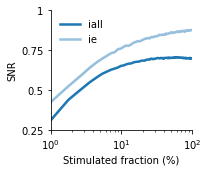

In [ ]:
SHOW_SEM = True
EPS = 1e-12

CSV_IALL = "data/fig4_5/iall_pattern_completion_stim_rates_summary.csv"
CSV_IE   = "data/fig4_5/ie_pattern_completion_stim_rates_summary.csv"

BLUE = "#1f77b4"  # inh
RED  = "#d62728"  # exc

def load_and_compute(csv_path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    for c in [
        "seed", "stim_level",
        "inh_rate_0_to_196", "inh_rate_196_to_2000",
        "exc_rate_stim_to_784", "exc_rate_784_to_8000",
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["x"] = (df["stim_level"] * 7.0) * 100.0 / 784.0

    S_inh = df["inh_rate_0_to_196"]
    N_inh = df["inh_rate_196_to_2000"]
    df["sn_inh"] = (S_inh - N_inh) / (S_inh + N_inh + EPS)

    S_exc = df["exc_rate_stim_to_784"]
    N_exc = df["exc_rate_784_to_8000"]
    df["sn_exc"] = (S_exc - N_exc) / (S_exc + N_exc + EPS)

    df["case"] = label
    return df[["x", "seed", "sn_exc", "sn_inh", "case"]]

def aggregate_mean_sem(df: pd.DataFrame, ycol: str) -> pd.DataFrame:
    g = df.groupby("x")[ycol]
    out = g.mean().rename("mean").to_frame().reset_index()
    if SHOW_SEM:
        n = g.count().rename("n").reset_index()
        sd = g.std(ddof=1).rename("sd").reset_index()
        out = out.merge(n, on="x").merge(sd, on="x")
        out["sem"] = out["sd"] / np.sqrt(out["n"].replace(0, np.nan))
    else:
        out["sem"] = np.nan
    return out.sort_values("x")

df_iall = load_and_compute(CSV_IALL, "iall")
df_ie   = load_and_compute(CSV_IE,   "ie")

# exc SNR
agg_iall_exc = aggregate_mean_sem(df_iall, "sn_exc")
agg_ie_exc   = aggregate_mean_sem(df_ie,   "sn_exc")

fig1, ax1 = plt.subplots(figsize=(3, 2.5))

ax1.plot(agg_iall_exc["x"], agg_iall_exc["mean"], color=RED, linewidth=2.5, label="iall")
ax1.plot(agg_ie_exc["x"],   agg_ie_exc["mean"],   color=RED, linewidth=2.5, alpha=0.45, label="ie")

if SHOW_SEM:
    ax1.fill_between(
        agg_iall_exc["x"],
        agg_iall_exc["mean"] - agg_iall_exc["sem"],
        agg_iall_exc["mean"] + agg_iall_exc["sem"],
        color=RED, alpha=0.12, linewidth=0
    )
    ax1.fill_between(
        agg_ie_exc["x"],
        agg_ie_exc["mean"] - agg_ie_exc["sem"],
        agg_ie_exc["mean"] + agg_ie_exc["sem"],
        color=RED, alpha=0.06, linewidth=0
    )

ax1.set_xlabel("Stimulated fraction (%)")
ax1.set_ylabel("SNR")
ax1.set_xlim(1, 100)
ax1.set_ylim(0.25,  1)
ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
ax1.set_yticklabels(["0.25", "0.5", "0.75", "1"])
ax1.set_xscale("log")
ax1.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False)
plt.tight_layout()

# inh SNR
agg_iall_inh = aggregate_mean_sem(df_iall, "sn_inh")
agg_ie_inh   = aggregate_mean_sem(df_ie,   "sn_inh")

fig2, ax2 = plt.subplots(figsize=(3, 2.5))

ax2.plot(agg_iall_inh["x"], agg_iall_inh["mean"], color=BLUE, linewidth=2.5, label="iall")
ax2.plot(agg_ie_inh["x"],   agg_ie_inh["mean"],   color=BLUE, linewidth=2.5, alpha=0.45, label="ie")

if SHOW_SEM:
    ax2.fill_between(
        agg_iall_inh["x"],
        agg_iall_inh["mean"] - agg_iall_inh["sem"],
        agg_iall_inh["mean"] + agg_iall_inh["sem"],
        color=BLUE, alpha=0.12, linewidth=0
    )
    ax2.fill_between(
        agg_ie_inh["x"],
        agg_ie_inh["mean"] - agg_ie_inh["sem"],
        agg_ie_inh["mean"] + agg_ie_inh["sem"],
        color=BLUE, alpha=0.06, linewidth=0
    )

ax2.set_xlabel("Stimulated fraction (%)")
ax2.set_ylabel("SNR")
ax2.set_xlim(1, 100)
ax2.set_ylim(0.25,  1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0.25", "0.5", "0.75", "1"])
ax2.set_xscale("log")
ax2.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()

plt.show()

## Fig 5: Co-active ISP enhances disinhibition-driven engram recall.

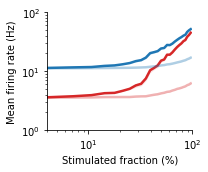

In [6]:
CSV_PATH = "data/fig4_5/iall_pattern_completion_inhib_rates_summary.csv"
SHOW_SEM = True

df = pd.read_csv(CSV_PATH)

for c in [
    "stim_level",
    "exc_rate_0_to_784", "exc_rate_784_to_8000",
    "inh_rate_stim_to_196", "inh_rate_196_to_2000",
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["x"] = (df["stim_level"] * 7.0) * 100.0 / 196.0

rate_cols = [
    "exc_rate_0_to_784",
    "exc_rate_784_to_8000",
    "inh_rate_stim_to_196",
    "inh_rate_196_to_2000",
]

g = df.groupby("x")[rate_cols]
mean_df = g.mean().reset_index()

if SHOW_SEM:
    count_df = g.count().reset_index()
    std_df = g.std(ddof=1).reset_index()
    sem_df = std_df.copy()
    for col in rate_cols:
        sem_df[col] = std_df[col] / np.sqrt(count_df[col].replace(0, np.nan))
else:
    sem_df = None

x = mean_df["x"].to_numpy()

BLUE = "#1f77b4"  
RED  = "#d62728" 

fig, ax = plt.subplots(figsize=(3, 2.5))


ax.plot(x, mean_df["exc_rate_0_to_784"],
        color=RED, linewidth=2.5, label="Exc 0–784")

ax.plot(x, mean_df["exc_rate_784_to_8000"],
        color=RED, linewidth=2.5, alpha=0.35, label="Exc 784–8000")

ax.plot(x, mean_df["inh_rate_stim_to_196"],
        color=BLUE, linewidth=2.5, label="Inh stim→196")

ax.plot(x, mean_df["inh_rate_196_to_2000"],
        color=BLUE, linewidth=2.5, alpha=0.35, label="Inh 196–2000")


if SHOW_SEM:
    def shade(ycol, color, alpha):
        y = mean_df[ycol].to_numpy()
        s = sem_df[ycol].to_numpy()
        ax.fill_between(x, y - s, y + s,
                        color=color, alpha=alpha, linewidth=0)

    shade("exc_rate_0_to_784", RED, 0.12)
    shade("exc_rate_784_to_8000", RED, 0.06)
    shade("inh_rate_stim_to_196", BLUE, 0.12)
    shade("inh_rate_196_to_2000", BLUE, 0.06)

ax.set_xlim(4, 100)
ax.set_ylim(1, 100)
ax.set_xlabel("Stimulated fraction (%)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_xscale("log")
ax.set_yscale("log")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()


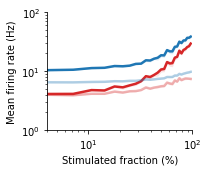

In [7]:
CSV_PATH = "data/fig4_5/ie_pattern_completion_inhib_rates_summary.csv"
SHOW_SEM = True

df = pd.read_csv(CSV_PATH)

for c in [
    "stim_level",
    "exc_rate_0_to_784", "exc_rate_784_to_8000",
    "inh_rate_stim_to_196", "inh_rate_196_to_2000",
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["x"] = (df["stim_level"] * 7.0) * 100.0 / 196.0

rate_cols = [
    "exc_rate_0_to_784",
    "exc_rate_784_to_8000",
    "inh_rate_stim_to_196",
    "inh_rate_196_to_2000",
]

g = df.groupby("x")[rate_cols]
mean_df = g.mean().reset_index()

if SHOW_SEM:
    count_df = g.count().reset_index()
    std_df = g.std(ddof=1).reset_index()
    sem_df = std_df.copy()
    for col in rate_cols:
        sem_df[col] = std_df[col] / np.sqrt(count_df[col].replace(0, np.nan))
else:
    sem_df = None

x = mean_df["x"].to_numpy()

BLUE = "#1f77b4" 
RED  = "#d62728" 

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.plot(x, mean_df["exc_rate_0_to_784"],
        color=RED, linewidth=2.5, label="Exc 0–784")

ax.plot(x, mean_df["exc_rate_784_to_8000"],
        color=RED, linewidth=2.5, alpha=0.35, label="Exc 784–8000")

ax.plot(x, mean_df["inh_rate_stim_to_196"],
        color=BLUE, linewidth=2.5, label="Inh stim→196")

ax.plot(x, mean_df["inh_rate_196_to_2000"],
        color=BLUE, linewidth=2.5, alpha=0.35, label="Inh 196–2000")

if SHOW_SEM:
    def shade(ycol, color, alpha):
        y = mean_df[ycol].to_numpy()
        s = sem_df[ycol].to_numpy()
        ax.fill_between(x, y - s, y + s,
                        color=color, alpha=alpha, linewidth=0)

    shade("exc_rate_0_to_784", RED, 0.12)
    shade("exc_rate_784_to_8000", RED, 0.06)
    shade("inh_rate_stim_to_196", BLUE, 0.12)
    shade("inh_rate_196_to_2000", BLUE, 0.06)

ax.set_xlim(4, 100)
ax.set_ylim(1, 100)
ax.set_xlabel("Stimulated fraction (%)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_xscale("log")
ax.set_yscale("log")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


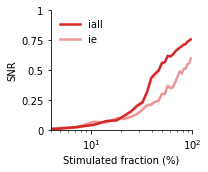

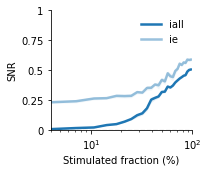

In [ ]:
SHOW_SEM = True
EPS = 1e-12

CSV_IALL = "data/fig4_5/iall_pattern_completion_inhib_rates_summary.csv"
CSV_IE   = "data/fig4_5/ie_pattern_completion_inhib_rates_summary.csv"

BLUE = "#1f77b4"  
RED  = "#d62728" 

def load_and_compute(csv_path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    for c in [
        "seed", "stim_level",
        "exc_rate_0_to_784", "exc_rate_784_to_8000",
        "inh_rate_stim_to_196", "inh_rate_196_to_2000",
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["x"] = (df["stim_level"] * 7.0) * 100.0 / 196.0

    S_exc = df["exc_rate_0_to_784"]
    N_exc = df["exc_rate_784_to_8000"]
    df["sn_exc"] = (S_exc - N_exc) / (S_exc + N_exc + EPS)

    S_inh = df["inh_rate_stim_to_196"]
    N_inh = df["inh_rate_196_to_2000"]
    df["sn_inh"] = (S_inh - N_inh) / (S_inh + N_inh + EPS)

    df["case"] = label
    return df[["x", "seed", "sn_exc", "sn_inh", "case"]]

def aggregate_mean_sem(df: pd.DataFrame, ycol: str) -> pd.DataFrame:
    g = df.groupby("x")[ycol]
    out = g.mean().rename("mean").to_frame().reset_index()
    if SHOW_SEM:
        n = g.count().rename("n").reset_index()
        sd = g.std(ddof=1).rename("sd").reset_index()
        out = out.merge(n, on="x").merge(sd, on="x")
        out["sem"] = out["sd"] / np.sqrt(out["n"].replace(0, np.nan))
    else:
        out["sem"] = np.nan
    return out.sort_values("x")

df_iall = load_and_compute(CSV_IALL, "iall")
df_ie   = load_and_compute(CSV_IE,   "ie")

# exc SNR
agg_iall_exc = aggregate_mean_sem(df_iall, "sn_exc")
agg_ie_exc   = aggregate_mean_sem(df_ie,   "sn_exc")

fig1, ax1 = plt.subplots(figsize=(3, 2.5))

ax1.plot(agg_iall_exc["x"], agg_iall_exc["mean"], color=RED, linewidth=2.5, label="iall")
ax1.plot(agg_ie_exc["x"],   agg_ie_exc["mean"],   color=RED, linewidth=2.5, alpha=0.45, label="ie")

if SHOW_SEM:
    ax1.fill_between(
        agg_iall_exc["x"],
        agg_iall_exc["mean"] - agg_iall_exc["sem"],
        agg_iall_exc["mean"] + agg_iall_exc["sem"],
        color=RED, alpha=0.12, linewidth=0
    )
    ax1.fill_between(
        agg_ie_exc["x"],
        agg_ie_exc["mean"] - agg_ie_exc["sem"],
        agg_ie_exc["mean"] + agg_ie_exc["sem"],
        color=RED, alpha=0.06, linewidth=0
    )

ax1.set_xlabel("Stimulated fraction (%)")
ax1.set_ylabel("SNR")
ax1.set_xlim(4, 100)
ax1.set_ylim(0, 1)
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax1.set_yticklabels(["0", "0.25", "0.5", "0.75", "1"])
ax1.set_xscale("log")
ax1.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False)
plt.tight_layout()

# inh SNR
agg_iall_inh = aggregate_mean_sem(df_iall, "sn_inh")
agg_ie_inh   = aggregate_mean_sem(df_ie,   "sn_inh")

fig2, ax2 = plt.subplots(figsize=(3, 2.5))

ax2.plot(agg_iall_inh["x"], agg_iall_inh["mean"], color=BLUE, linewidth=2.5, label="iall")
ax2.plot(agg_ie_inh["x"],   agg_ie_inh["mean"],   color=BLUE, linewidth=2.5, alpha=0.45, label="ie")

if SHOW_SEM:
    ax2.fill_between(
        agg_iall_inh["x"],
        agg_iall_inh["mean"] - agg_iall_inh["sem"],
        agg_iall_inh["mean"] + agg_iall_inh["sem"],
        color=BLUE, alpha=0.12, linewidth=0
    )
    ax2.fill_between(
        agg_ie_inh["x"],
        agg_ie_inh["mean"] - agg_ie_inh["sem"],
        agg_ie_inh["mean"] + agg_ie_inh["sem"],
        color=BLUE, alpha=0.06, linewidth=0
    )

ax2.set_xlabel("Stimulated fraction (%)")
ax2.set_ylabel("SNR")
ax2.set_xlim(4, 100)
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0", "0.25", "0.5", "0.75", "1"])
ax2.set_xscale("log")
ax2.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()


## Fig S4: Stimulation-driven engram-only recall in the networks with co-active ISP.

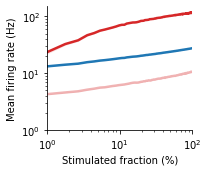

In [10]:
CSV_PATH = "data/fig4_5/iall_engram_pattern_completion_stim_rates_summary.csv"
SHOW_SEM = True

df = pd.read_csv(CSV_PATH)

for c in [
    "stim_level",
    "exc_rate_stim_to_784", "exc_rate_784_to_8000",
    "inh_rate_0_to_2000",
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["x"] = (df["stim_level"] * 7.0) * 100.0 / 784.0

rate_cols = [
    "exc_rate_stim_to_784",
    "exc_rate_784_to_8000",
    "inh_rate_0_to_2000",
]

g = df.groupby("x")[rate_cols]
mean_df = g.mean().reset_index()

if SHOW_SEM:
    count_df = g.count().reset_index()
    std_df = g.std(ddof=1).reset_index()
    sem_df = std_df.copy()
    for col in rate_cols:
        sem_df[col] = std_df[col] / np.sqrt(count_df[col].replace(0, np.nan))
else:
    sem_df = None

x = mean_df["x"].to_numpy()

BLUE = "#1f77b4" 
RED  = "#d62728" 

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.plot(
    x,
    mean_df["inh_rate_0_to_2000"],
    color=BLUE,
    linewidth=2.5,
    label="Inh 0-2000"
)

ax.plot(
    x,
    mean_df["exc_rate_stim_to_784"],
    color=RED,
    linewidth=2.5,
    label="Exc stim 784"
)
ax.plot(
    x,
    mean_df["exc_rate_784_to_8000"],
    color=RED,
    linewidth=2.5,
    alpha=0.35,
    label="Exc 784-8000"
)

if SHOW_SEM:
    def shade(ycol, color, alpha):
        y = mean_df[ycol].to_numpy()
        s = sem_df[ycol].to_numpy()
        ax.fill_between(x, y - s, y + s, color=color, alpha=alpha, linewidth=0)

    shade("inh_rate_0_to_2000", BLUE, 0.12)
    shade("exc_rate_stim_to_784", RED, 0.12)
    shade("exc_rate_784_to_8000", RED, 0.06)

ax.set_xlim(1, 100)
ax.set_ylim(1, 150)
ax.set_xlabel("Stimulated fraction (%)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_xscale("log")
ax.set_yscale("log")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()


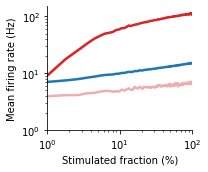

In [11]:
CSV_PATH = "data/fig4_5/ie_engram_pattern_completion_stim_rates_summary.csv"
SHOW_SEM = True

df = pd.read_csv(CSV_PATH)

for c in [
    "stim_level",
    "exc_rate_stim_to_784", "exc_rate_784_to_8000",
    "inh_rate_0_to_2000",
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["x"] = (df["stim_level"] * 7.0) * 100.0 / 784.0

rate_cols = [
    "exc_rate_stim_to_784",
    "exc_rate_784_to_8000",
    "inh_rate_0_to_2000",
]

g = df.groupby("x")[rate_cols]
mean_df = g.mean().reset_index()

if SHOW_SEM:
    count_df = g.count().reset_index()
    std_df = g.std(ddof=1).reset_index()
    sem_df = std_df.copy()
    for col in rate_cols:
        sem_df[col] = std_df[col] / np.sqrt(count_df[col].replace(0, np.nan))
else:
    sem_df = None

x = mean_df["x"].to_numpy()

BLUE = "#1f77b4" 
RED  = "#d62728" 

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.plot(
    x,
    mean_df["inh_rate_0_to_2000"],
    color=BLUE,
    linewidth=2.5,
    label="Inh 0-2000"
)

ax.plot(
    x,
    mean_df["exc_rate_stim_to_784"],
    color=RED,
    linewidth=2.5,
    label="Exc stim 784"
)
ax.plot(
    x,
    mean_df["exc_rate_784_to_8000"],
    color=RED,
    linewidth=2.5,
    alpha=0.35,
    label="Exc 784-8000"
)

if SHOW_SEM:
    def shade(ycol, color, alpha):
        y = mean_df[ycol].to_numpy()
        s = sem_df[ycol].to_numpy()
        ax.fill_between(x, y - s, y + s, color=color, alpha=alpha, linewidth=0)

    shade("inh_rate_0_to_2000", BLUE, 0.12)
    shade("exc_rate_stim_to_784", RED, 0.12)
    shade("exc_rate_784_to_8000", RED, 0.06)

ax.set_xlim(1, 100)
ax.set_ylim(1, 150)
ax.set_xlabel("Stimulated fraction (%)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_xscale("log")
ax.set_yscale("log")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()


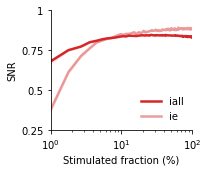

In [12]:
SHOW_SEM = True
EPS = 1e-12

CSV_IALL = "data/fig4_5/iall_engram_pattern_completion_stim_rates_summary.csv"
CSV_IE   = "data/fig4_5/ie_engram_pattern_completion_stim_rates_summary.csv"

RED = "#d62728"

def load_and_compute_exc(csv_path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    for c in ["seed", "stim_level", "exc_rate_stim_to_784", "exc_rate_784_to_8000"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["x"] = (df["stim_level"] * 7.0) * 100.0 / 784.0

    S_exc = df["exc_rate_stim_to_784"]
    N_exc = df["exc_rate_784_to_8000"]
    df["sn_exc"] = (S_exc - N_exc) / (S_exc + N_exc + EPS)

    df["case"] = label
    return df[["x", "seed", "sn_exc", "case"]]

def aggregate_mean_sem(df: pd.DataFrame, ycol: str) -> pd.DataFrame:
    g = df.groupby("x")[ycol]
    out = g.mean().rename("mean").to_frame().reset_index()
    if SHOW_SEM:
        n = g.count().rename("n").reset_index()
        sd = g.std(ddof=1).rename("sd").reset_index()
        out = out.merge(n, on="x").merge(sd, on="x")
        out["sem"] = out["sd"] / np.sqrt(out["n"].replace(0, np.nan))
    else:
        out["sem"] = np.nan
    return out.sort_values("x")

df_iall = load_and_compute_exc(CSV_IALL, "iall")
df_ie   = load_and_compute_exc(CSV_IE,   "ie")

agg_iall = aggregate_mean_sem(df_iall, "sn_exc")
agg_ie   = aggregate_mean_sem(df_ie,   "sn_exc")

# exc SNR
fig, ax = plt.subplots(figsize=(3, 2.5))

ax.plot(agg_iall["x"], agg_iall["mean"], color=RED, linewidth=2.5, label="iall")
ax.plot(agg_ie["x"],   agg_ie["mean"],   color=RED, linewidth=2.5, alpha=0.45, label="ie")

if SHOW_SEM:
    ax.fill_between(
        agg_iall["x"],
        agg_iall["mean"] - agg_iall["sem"],
        agg_iall["mean"] + agg_iall["sem"],
        color=RED, alpha=0.12, linewidth=0
    )
    ax.fill_between(
        agg_ie["x"],
        agg_ie["mean"] - agg_ie["sem"],
        agg_ie["mean"] + agg_ie["sem"],
        color=RED, alpha=0.06, linewidth=0
    )

ax.set_xlabel("Stimulated fraction (%)")
ax.set_ylabel("SNR")
ax.set_xlim(1, 100)
ax.set_ylim(0.25, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.5", "0.75", "1"])
ax.set_xscale("log")

ax.axhline(0, linestyle="--", linewidth=1.2, color="k", alpha=0.4)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()
